## Comparing the Mean Field and the corresponding Neural Network simulation results 

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we load the MF and NN simulation results (obtained using *MF_heatmap_data.py* and *NN_heatmap_data.py*) and compare them.

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt
import h5py

In [2]:
import sys 
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from ntmf.config import *
from utils.Plots_helper import *
import seaborn as sns
import numpy as np
import pandas as pd


In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [5]:
fig_name = 'MF_NN_comparison_step_1'

## FS

In [6]:
# Loading FS the data
df_mf = load_sim_data('simulations/val_MF_[0_30_1]', model_type="MF")
df_nn = load_sim_data('simulations/val_NN_[0_30_1]', model_type="NN")

In [7]:
## to add in Plots_helper.py ##

import numpy as np

def get_pivot(df, val):
    return df.pivot_table(index='inh', columns='exc', values=val)

def shared_limits(*pivots):
    """Common (vmin, vmax) across several pivot tables, so paired heatmaps
    (e.g. NN and MF) are drawn on the SAME colour scale and can be compared
    by eye."""
    lo = min(np.nanmin(p.values) for p in pivots)
    hi = max(np.nanmax(p.values) for p in pivots)
    return lo, hi

# -------------------- #
def plot_heatmap_simulation(neuron_model, model, df_data, annotate=False,
                            vmin=None, vmax=None, ax=None, cbar=True):
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = plt.gca()
    else:
        fig = ax.figure
    sns.heatmap(df_data, annot=annotate, fmt=".1f", cmap="viridis",
                vmin=vmin, vmax=vmax, ax=ax, cbar=cbar,
                cbar_kws={'label': 'Output Freq (Hz)'})
    ax.invert_yaxis()
    ax.set_xlabel('Input Freq Exc Syn (Hz)')
    ax.set_ylabel('Input Freq Inh Syn (Hz)')
    ax.set_title(f'{neuron_model} {model} Results')
    ax.set_box_aspect(1)
    return fig

# -------------------- #
def plot_heatmap_diff_simulation(
        neuron_model,
        df_data,
        annotate=False,
        vmax_abs=None,
        ax=None,
        cbar=True,
        cbar_ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    if vmax_abs is None:
        vmax_abs = np.nanmax(np.abs(df_data.to_numpy()))

    sns.heatmap(
        df_data,
        annot=annotate,
        fmt='.1f',
        cmap='PRGn_r',
        center=0,
        vmin=-vmax_abs,
        vmax=vmax_abs,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={'label': 'MF - NN (Hz)'},
    )

    ax.invert_yaxis()
    ax.set_xlabel('Input Freq Exc Syn (Hz)')
    ax.set_ylabel('Input Freq Inh Syn (Hz)')
    ax.set_title(f'{neuron_model} difference (MF − NN)')

    return fig
# -------------------- #
def plot_heatmap_z_score(neuron_model, df_data, annotate=False, ax=None):
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = plt.gca()
    else:
        fig = ax.figure
    sns.heatmap(df_data, annot=annotate, fmt=".1f", cmap="PRGn_r", center=0,
                vmin=-2, vmax=+2, ax=ax, cbar_kws={'label': 'Z-score'})
    ax.invert_yaxis()
    ax.set_xlabel('Input Freq Exc Syn (Hz)')
    ax.set_ylabel('Input Freq Inh Syn (Hz)')
    ax.set_title(f'Z-score: {neuron_model} (MF-NN) / NN_std')
    return fig

# -------------------- #
def plot_mismatch_heatmap(neuron_model, df_data, annotate=False, ax=None):
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = plt.gca()
    else:
        fig = ax.figure
    sns.heatmap(df_data, cmap="YlOrRd", ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel('Input Freq Exc Syn (Hz)')
    ax.set_ylabel('Input Freq Inh Syn (Hz)')
    ax.set_title(f'{neuron_model} --> Significant Mismatch (MF > 2 sigma from NN)')
    return fig

# -------------------- #
def parity_metrics(nn, mf):
    """RMSE, Pearson r, and OLS slope/intercept of MF vs NN (flattened)."""
    nn = np.asarray(nn, float).ravel()
    mf = np.asarray(mf, float).ravel()
    m = np.isfinite(nn) & np.isfinite(mf)
    nn, mf = nn[m], mf[m]
    rmse = np.sqrt(np.mean((mf - nn) ** 2))
    r = np.corrcoef(nn, mf)[0, 1] if len(nn) > 1 else np.nan
    slope, intercept = np.polyfit(nn, mf, 1) if len(nn) > 1 else (np.nan, np.nan)
    return dict(rmse=rmse, r=r, r2=r**2, slope=slope, intercept=intercept, n=len(nn))

def plot_identity_scatter(series, ax=None):
    """series : list of (label, nn_pivot, mf_pivot, color).
    Draws MF vs NN with the y=x line and prints per-population metrics."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure
    hi = 0.0
    txt = []
    for label, nn, mf, color in series:
        x = np.asarray(nn.values, float).ravel()
        y = np.asarray(mf.values, float).ravel()
        ax.scatter(x, y, s=28, alpha=0.8, color=color, edgecolor='k',
                   linewidth=0.3, label=label)
        hi = max(hi, np.nanmax(x), np.nanmax(y))
        mt = parity_metrics(x, y)
        txt.append(f"{label}: R\u00b2={mt['r2']:.3f}, RMSE={mt['rmse']:.2f} Hz, "
                   f"slope={mt['slope']:.2f}")
    hi *= 1.05
    ax.plot([0, hi], [0, hi], 'k--', lw=1, zorder=0)
    ax.set_xlim(0, hi); ax.set_ylim(0, hi); ax.set_aspect('equal')
    ax.set_xlabel('NN rate (Hz)'); ax.set_ylabel('MF rate (Hz)')
    ax.set_title('MF vs NN (identity)')
    ax.legend(fontsize=8, loc='upper left')
    ax.text(0.98, 0.02, "\n".join(txt), transform=ax.transAxes, fontsize=7,
            ha='right', va='bottom')
    return fig

def plot_line_profiles(neuron_model, mf_pivot, nn_pivot, nn_std_pivot,
                       inh_levels, color, ax=None):
    """Response vs excitatory input at a few fixed inhibition levels.
    MF drawn as a line, NN as points +/- its temporal std."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure
    exc = mf_pivot.columns.values
    alphas = np.linspace(0.4, 1.0, len(inh_levels))
    for a, inh in zip(alphas, inh_levels):
        ax.plot(exc, mf_pivot.loc[inh].values, '-', color=color, alpha=a,
                label=f'MF, inh={inh}')
        ax.errorbar(exc, nn_pivot.loc[inh].values,
                    yerr=nn_std_pivot.loc[inh].values, fmt='o', ms=4,
                    color=color, alpha=a, capsize=2, label=f'NN, inh={inh}')
    ax.set_xlabel('Input Freq Exc Syn (Hz)')
    ax.set_ylabel('Output Freq (Hz)')
    ax.set_title(f'{neuron_model} response profiles')
    ax.legend(fontsize=7, ncol=2)
    return fig

def assemble_figure6(fs, rs):
    """fs, rs : dict with keys nn, mf, diff (pivot tables) and color.
    Builds the 2x4 composite: NN | MF | MF-NN | parity, one row per pop."""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 4, figsize=(19, 9))
    for row, (name, d) in enumerate([('FS', fs), ('RS', rs)]):
        vmin, vmax = shared_limits(d['nn'], d['mf'])
        vmax_abs = np.nanmax(np.abs(d['diff'].values))
        plot_heatmap_simulation(name, 'NN', d['nn'], vmin=vmin, vmax=vmax, ax=axes[row, 0])
        plot_heatmap_simulation(name, 'MF', d['mf'], vmin=vmin, vmax=vmax, ax=axes[row, 1])
        plot_heatmap_diff_simulation(name, d['diff'], vmax_abs=vmax_abs, ax=axes[row, 2])
        plot_identity_scatter([(name, d['nn'], d['mf'], d['color'])], ax=axes[row, 3])
    fig.suptitle('Figure 6 — Mean-field vs spiking-network validation', fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

def assemble_sub_figure6(fs, rs):
    import matplotlib.pyplot as plt

    panel_width = 17 / 3
    panel_height = 4.6

    fig = plt.figure(
        figsize=(2 * panel_width, 2 * panel_height),
        layout='constrained',
    )

    gs = fig.add_gridspec(
        2, 4,
        width_ratios=[1, 0.045, 1, 0.045],
        wspace=0.15,
        hspace=0.20,
    )

    axes = np.empty((2, 2), dtype=object)

    for row, (name, d) in enumerate([('FS', fs), ('RS', rs)]):
        ax_heatmap = fig.add_subplot(gs[row, 0])
        cax = fig.add_subplot(gs[row, 1])

        ax_scatter = fig.add_subplot(gs[row, 2])
        spacer_ax = fig.add_subplot(gs[row, 3])
        spacer_ax.axis('off')

        axes[row, 0] = ax_heatmap
        axes[row, 1] = ax_scatter

        vmax_abs = np.nanmax(np.abs(d['diff'].to_numpy()))

        plot_heatmap_diff_simulation(
            name,
            d['diff'],
            vmax_abs=vmax_abs,
            ax=ax_heatmap,
            cbar_ax=cax,
        )

        plot_identity_scatter(
            [(name, d['nn'], d['mf'], d['color'])],
            ax=ax_scatter,
        )

    #fig.suptitle(
    #    'Figure 6 — Mean-field vs spiking-network validation',
    #    fontsize=14,
    #)

    return fig, axes
    


In [8]:
fs_mf_data = get_pivot(df_mf, 'fs_avg')
fs_nn_data = get_pivot(df_nn, 'fs_avg')
fs_nn_std_data = get_pivot(df_nn, 'fs_std')

In [9]:
# Shared colour scale so the FS NN and MF maps are directly comparable
fs_vmin, fs_vmax = shared_limits(fs_mf_data, fs_nn_data)


### FS comparison plots

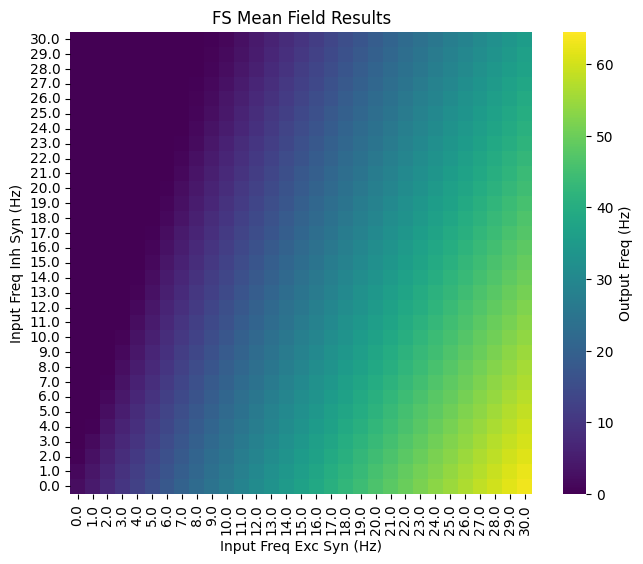

In [10]:
fig_fs_mf = plot_heatmap_simulation('FS', 'Mean Field', fs_mf_data, vmin=fs_vmin, vmax=fs_vmax)


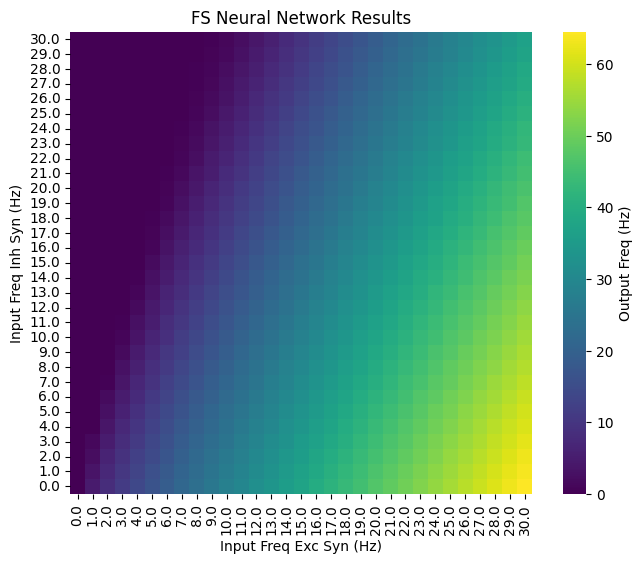

In [11]:
fig_fs_nn = plot_heatmap_simulation('FS', 'Neural Network', fs_nn_data, vmin=fs_vmin, vmax=fs_vmax)


In [12]:
# Computing the difference between MF and NN
fs_diff_data = fs_mf_data - fs_nn_data

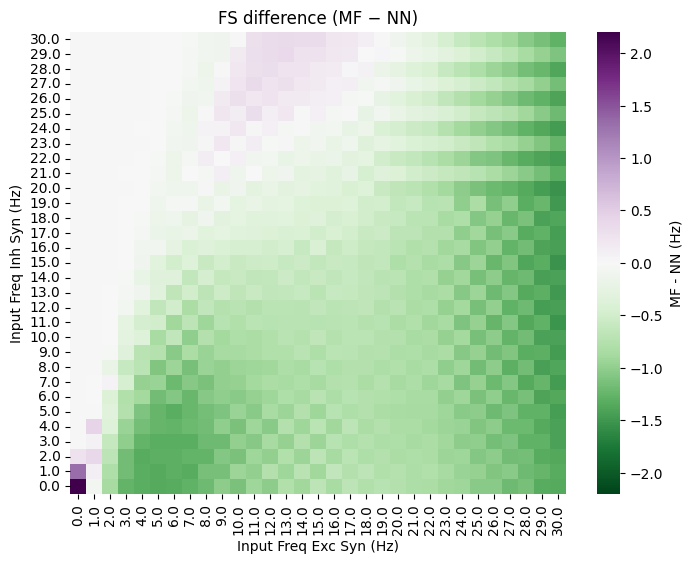

In [13]:
fig_fs_diff = plot_heatmap_diff_simulation('FS', fs_diff_data)


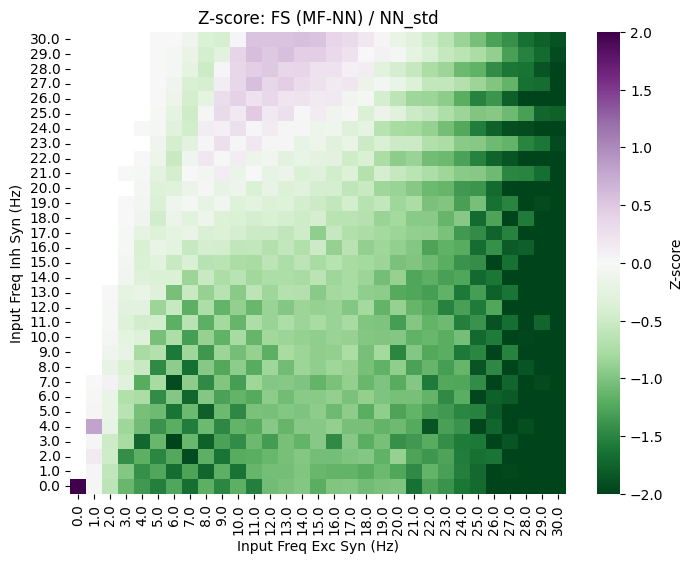

In [14]:
# Z-score = (MF - NN) / NN temporal std : is the MF inside the NN fluctuation band?
fs_z_score = (fs_mf_data - fs_nn_data) / fs_nn_std_data
fig_fs_z = plot_heatmap_z_score('FS', fs_z_score, annotate=False)


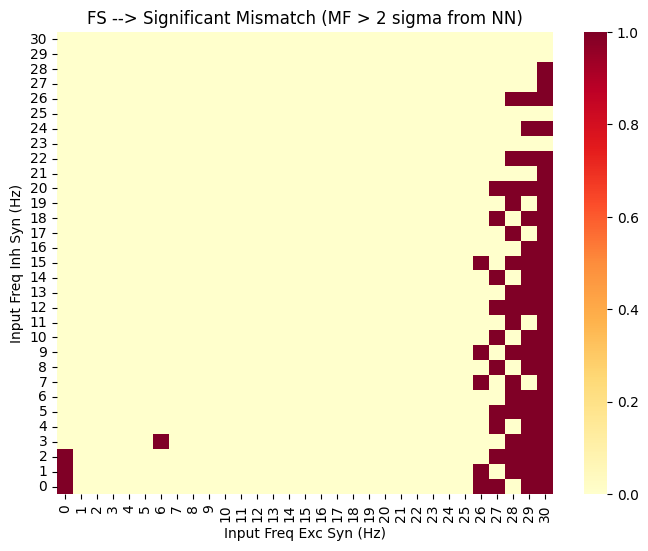

In [15]:
# Boolean mask: is the MF more than 2 std away?
eps = 1e-3  # avoid division by zero when fs_nn_std_data = 0
diff = np.abs(fs_mf_data - fs_nn_data)
mismatch_mask = np.where(fs_nn_std_data == 0, diff > eps, diff > 2 * fs_nn_std_data)
fig_fs_mismatch = plot_mismatch_heatmap('FS', mismatch_mask, annotate=False)


## RS

In [16]:
# Loading the results
rs_mf_data = get_pivot(df_mf, 'rs_avg')
rs_nn_data = get_pivot(df_nn, 'rs_avg')
rs_nn_std_data = get_pivot(df_nn, 'rs_std')

In [17]:
# Shared colour scale so the RS NN and MF maps are directly comparable
rs_vmin, rs_vmax = shared_limits(rs_mf_data, rs_nn_data)


### RS comparison plots

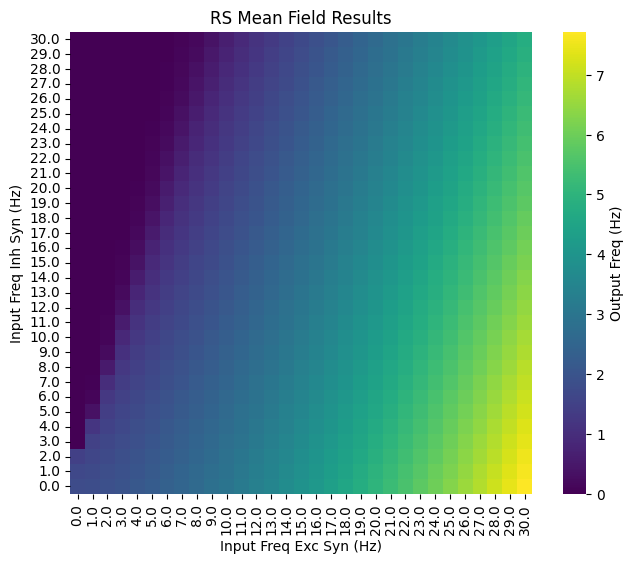

In [18]:
fig_rs_mf = plot_heatmap_simulation('RS', 'Mean Field', rs_mf_data, vmin=rs_vmin, vmax=rs_vmax)


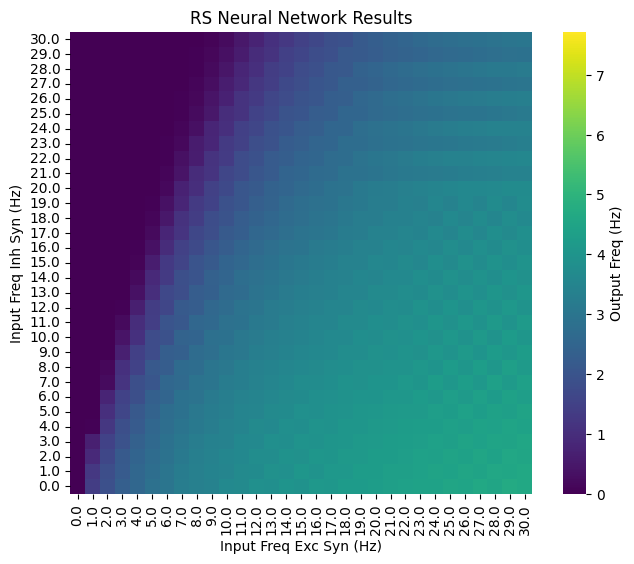

In [19]:
fig_rs_nn = plot_heatmap_simulation('RS', 'Neural Network', rs_nn_data, vmin=rs_vmin, vmax=rs_vmax)


In [20]:
rs_diff_data = rs_mf_data - rs_nn_data

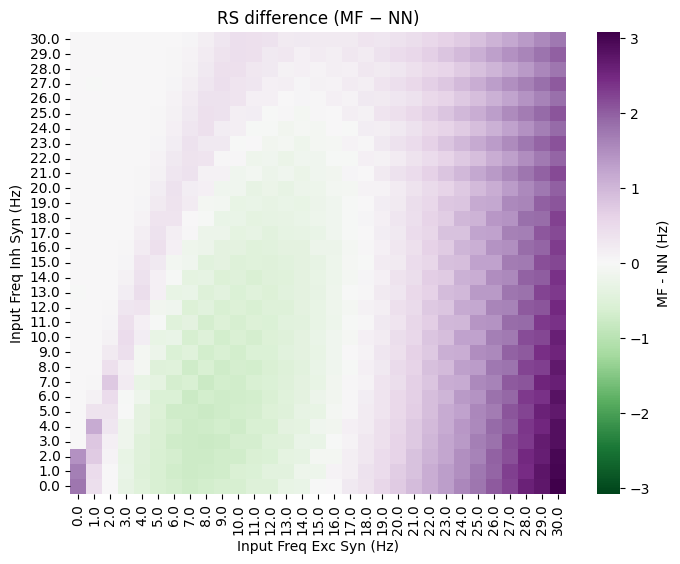

In [21]:
fig_rs_diff = plot_heatmap_diff_simulation('RS', rs_diff_data)


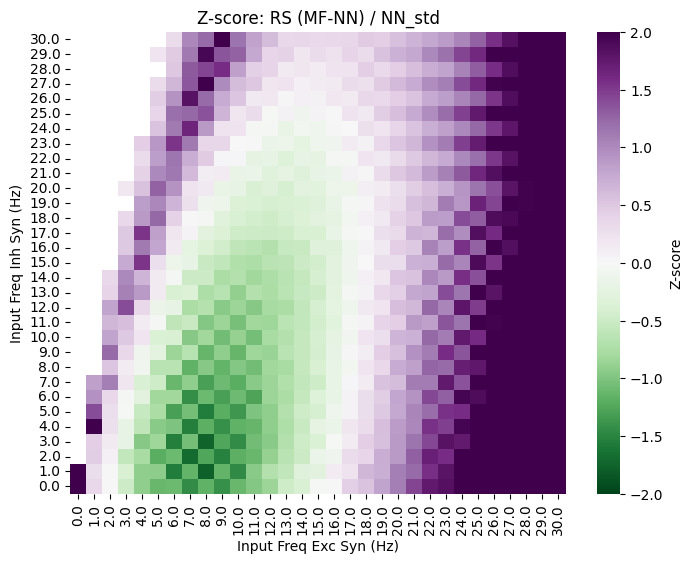

In [22]:
rs_z_score = (rs_mf_data - rs_nn_data) / rs_nn_std_data
fig_rs_z = plot_heatmap_z_score('RS', rs_z_score, annotate=False)


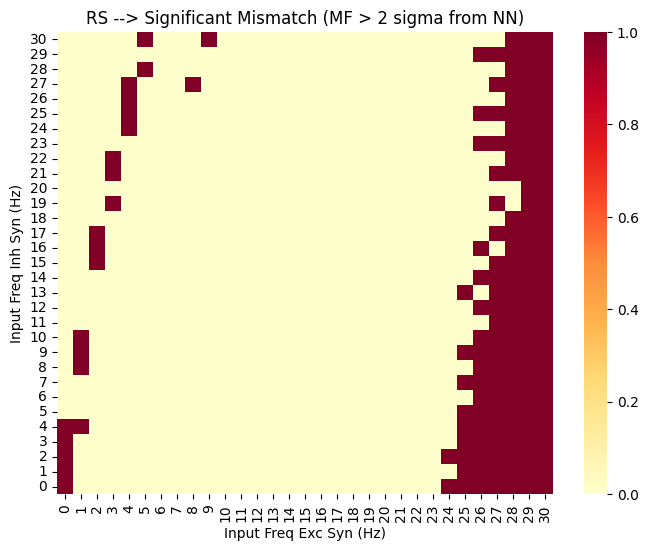

In [23]:
eps = 1e-3
diff = np.abs(rs_mf_data - rs_nn_data)
mismatch_mask = np.where(rs_nn_std_data == 0, diff > eps, diff > 2 * rs_nn_std_data)
fig_rs_mismatch = plot_mismatch_heatmap('RS', mismatch_mask, annotate=False)


## Quantitative validation: parity (MF vs NN)


FS: {'rmse': np.float64(0.7705839360855874), 'r': np.float64(0.9998470963584306), 'r2': np.float64(0.9996942160963849), 'slope': np.float64(0.9784812099564016), 'intercept': np.float64(-0.08663544919097897), 'n': 961}
RS: {'rmse': np.float64(0.9230333684887588), 'r': np.float64(0.919899218308527), 'r2': np.float64(0.8462145718446389), 'slope': np.float64(1.2307895512809464), 'intercept': np.float64(-0.17883638400637272), 'n': 961}


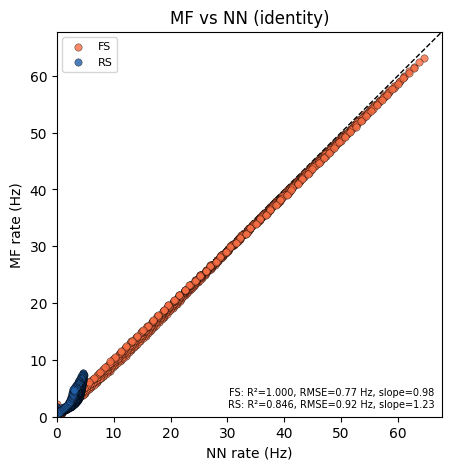

In [24]:
# Pooled identity / parity plot with error metrics per population
fig_parity = plot_identity_scatter([
    ('FS', fs_nn_data, fs_mf_data, color_palette['FS']),
    ('RS', rs_nn_data, rs_mf_data, color_palette['RS']),
])

print('FS:', parity_metrics(fs_nn_data.values, fs_mf_data.values))
print('RS:', parity_metrics(rs_nn_data.values, rs_mf_data.values))


## Response profiles (line cuts through the input grid)


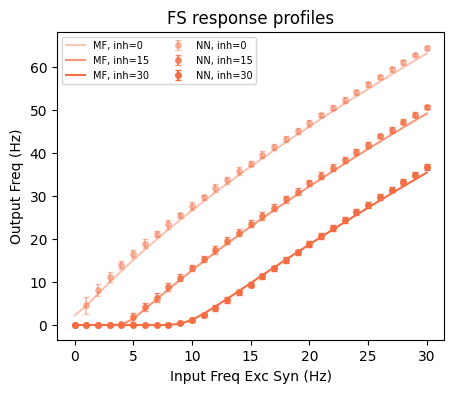

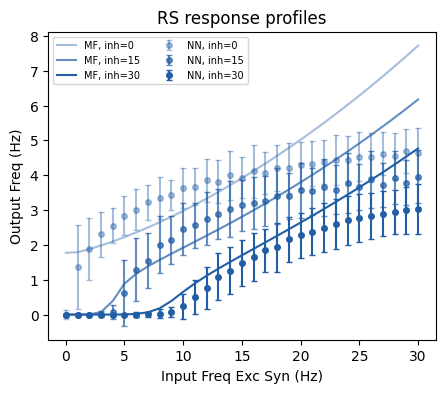

In [25]:
# Pick a few inhibition levels present in the grid
inh_levels = [lvl for lvl in [0, 15, 30] if lvl in fs_mf_data.index]

fig_prof_fs = plot_line_profiles('FS', fs_mf_data, fs_nn_data, fs_nn_std_data,
                                 inh_levels, color=color_palette['FS'])
fig_prof_rs = plot_line_profiles('RS', rs_mf_data, rs_nn_data, rs_nn_std_data,
                                 inh_levels, color=color_palette['RS'])


## Figure 6 (composite)


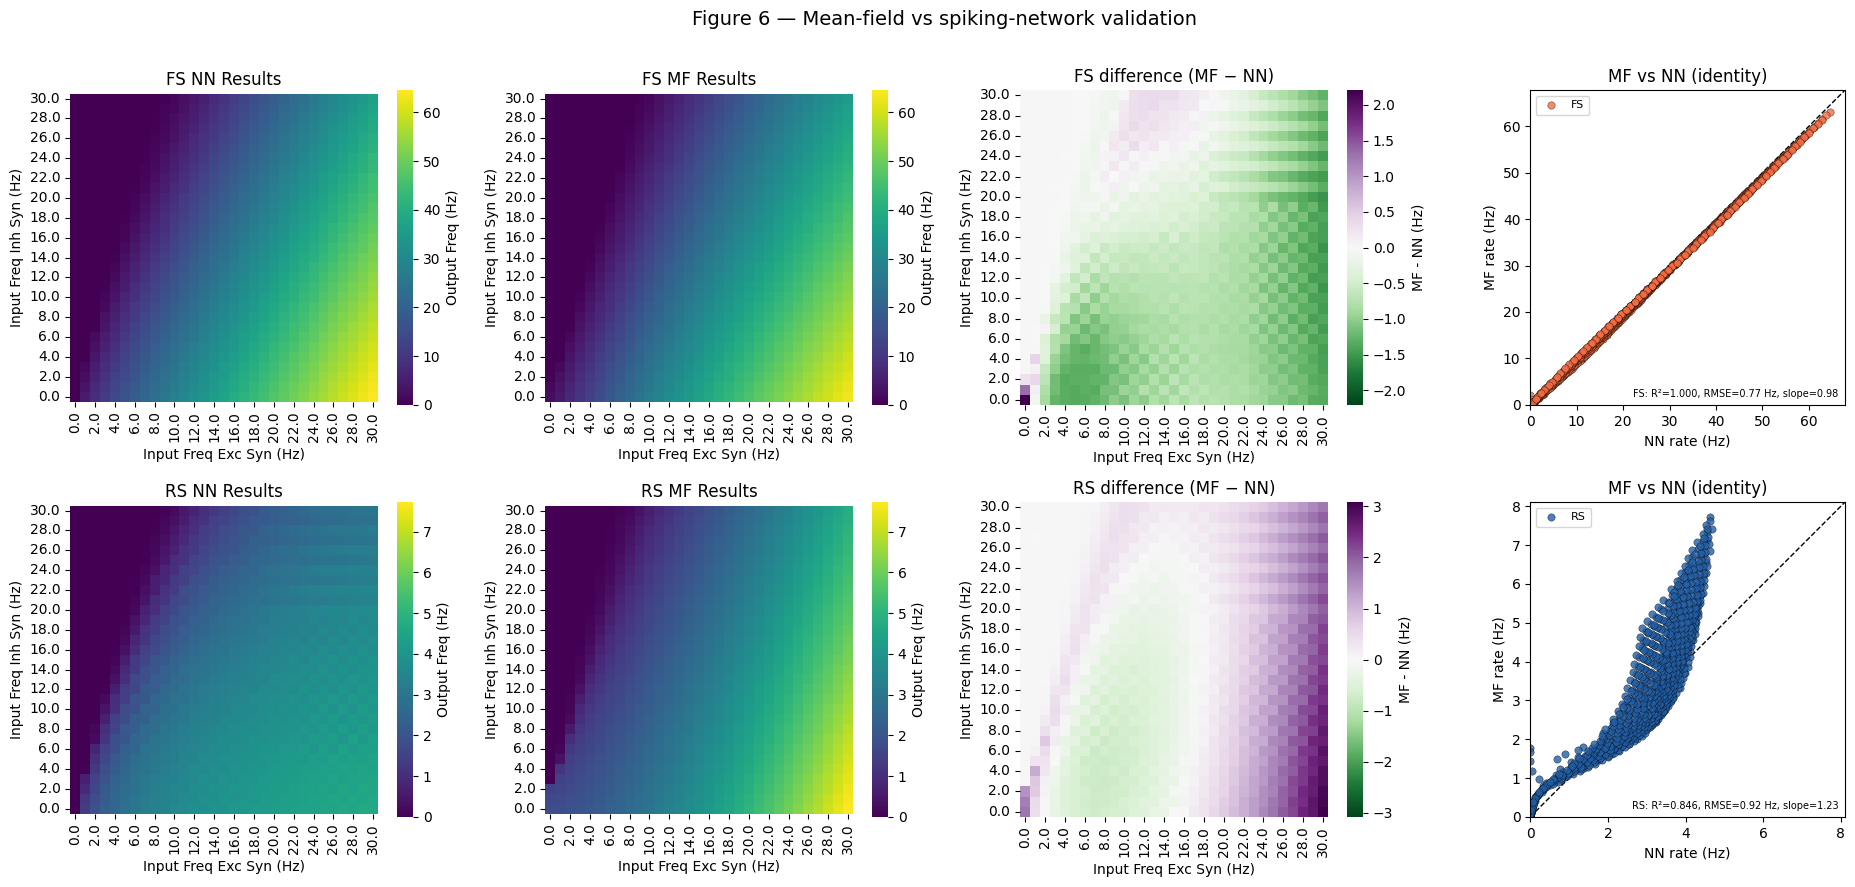

In [26]:
fig6 = assemble_figure6(
    fs={'nn': fs_nn_data, 'mf': fs_mf_data, 'diff': fs_diff_data, 'color': color_palette['FS']},
    rs={'nn': rs_nn_data, 'mf': rs_mf_data, 'diff': rs_diff_data, 'color': color_palette['RS']},
)
fig6.savefig(os.path.join(fig_path, 'figure6_MF_NN_validation.pdf'), bbox_inches='tight')
fig6.savefig(os.path.join(fig_path, 'figure6_MF_NN_validation.svg'), bbox_inches='tight')


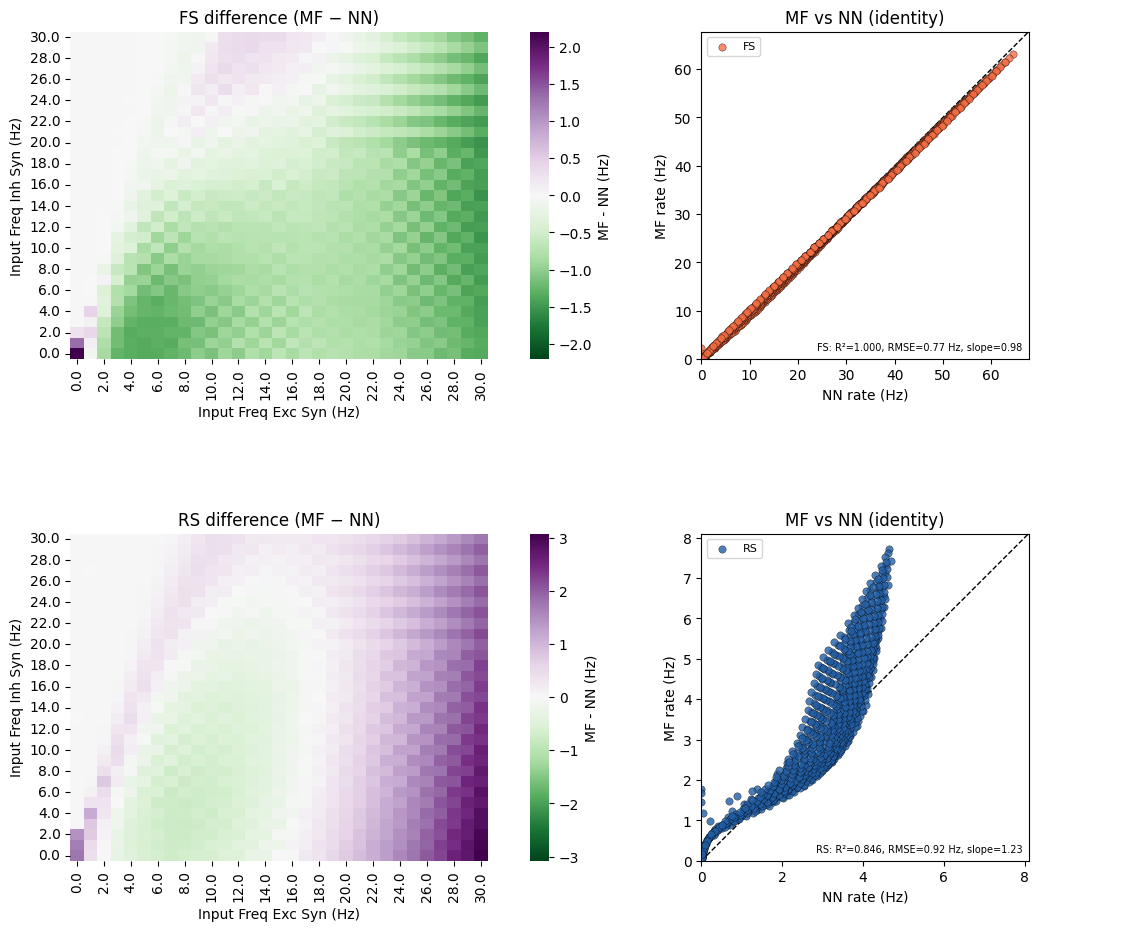

In [27]:
fig6_sub, _ = assemble_sub_figure6(
    fs={'nn': fs_nn_data, 'mf': fs_mf_data, 'diff': fs_diff_data, 'color': color_palette['FS']},
    rs={'nn': rs_nn_data, 'mf': rs_mf_data, 'diff': rs_diff_data, 'color': color_palette['RS']},
)
fig6_sub.savefig(os.path.join(fig_path, 'figure6_sub_panels_MF_NN_validation.pdf'), bbox_inches='tight')
fig6_sub.savefig(os.path.join(fig_path, 'figure6_sub_panels_MF_NN_validation.svg'), bbox_inches='tight')


In [28]:
# Main figure first, then supplementary diagnostics (z-score + mismatch)
figs = [fig6, fig_parity, fig_prof_fs, fig_prof_rs,
        fig_fs_z, fig_rs_z, fig_fs_mismatch, fig_rs_mismatch]


In [29]:
save_figs(fig_path, fig_name, figs)